# Análisis de imágenes para el control del robot — Escenario 1

**Autores:** Julio Lucero / Agostina Squillari

A partir del clasificador QDA entrenado en `segmentacion_QDA.ipynb`,
implementamos el pipeline completo de análisis de imagen que la unidad
de control del robot necesita para decidir qué hacer en cada frame:

1. **Suposiciones razonables** que simplifican el problema (basadas en
   las transparencias `transp.pdf`, p. 79-80).
2. **Detección de entradas y salidas** de la línea en cada escena.
3. **Clasificación de la escena** (recta, curva D/I, cruce 2 ó 3 salidas,
   fin de línea, sin línea).
4. **Orientación de la marca/flecha** y **salida seleccionada**.
5. **Error de seguimiento** de la línea.
6. **Consigna de control PD** que minimiza dicho error.

Toda la lógica vive en el módulo `analisis_escena.py` para que pueda
reutilizarse desde otros notebooks o desde un script de control en línea.
El presente notebook explica el razonamiento y valida el pipeline sobre
`video1.mp4`.

## 1. Suposiciones razonables del problema

Inspirándonos en lo expuesto en la página 79 del documento `transp.pdf`
("Análisis de imágenes de líneas — Asunciones razonables"):

* **A1.** Las líneas son **infinitas** dentro del campo de visión: nunca
  terminan en mitad de la imagen, solo cortan los bordes.
* **A2.** En un mismo frame **no se ven segmentos pasados ni futuros** del
  trazado, así que para el cálculo del error sólo procesamos la **banda
  inferior** del frame (la región inmediatamente delante del robot).
* **A3.** La **cámara está fija** sobre el robot mirando hacia adelante;
  el borde inferior de la imagen es lo que tiene "debajo" en el instante
  actual y, por tanto, suele ser la **entrada** del trazado.
* **A4.** La línea es siempre **azul saturado**, la marca **roja** y el
  suelo **verde-grisáceo de baja saturación**, por lo que el QDA del
  Escenario 1 es suficiente para separarlas.
* **A5.** Las marcas no aparecen en cruces compactos (cf. p. 80); cuando
  hay marca, **define la salida elegida** entre las disponibles.
* **A6.** Los píxeles aislados que el clasificador etiqueta como "línea"
  por sombras o bordes de baldosa son siempre **componentes conexas
  pequeñas**, así que se filtran por área mínima.
* **A7.** El robot avanza con **velocidad lineal positiva**; cuando se
  pierde la línea (escena `sin_linea`), la consigna lo detiene.

## 2. Importación del módulo y entrenamiento del QDA

In [1]:
import time
import warnings
from collections import Counter

import cv2
import numpy as np
import imageio.v2 as iio
from matplotlib import pyplot as plt

import analisis_escena as ae

warnings.filterwarnings('ignore', category=UserWarning)
%matplotlib inline

# Reentrenamos el QDA con la misma imagen etiquetada que en la primera parte
imNp    = iio.imread('imagen_original.png')
markImg = iio.imread('imagen_marcada.png')
clf = ae.entrenar_qda(imNp, markImg)
print('QDA entrenado con', clf.classes_, 'clases.')

QDA entrenado con [0 1 2] clases.


## 3. Detección de entradas y salidas

Para cada frame:

1. Segmentamos con el QDA → máscara de línea (booleana).
2. Calculamos las **componentes conexas** y descartamos las menores de
   ~200 px (suposición A6).
3. Para cada componente válida, miramos qué bordes corta y dónde:
   los bordes superior e inferior se proyectan sobre el eje X y los
   laterales sobre el eje Y. Cada intersección se reporta como un
   `Extremo` con su lado, posición, longitud y ángulo desde el centro.
4. Por convención (suposición A3), las intersecciones con el borde
   **inferior** son **entradas** y el resto son **salidas**.

A continuación se ilustra el procedimiento sobre cinco frames muy
distintos del vídeo:

In [2]:
cap = cv2.VideoCapture('video1.mp4')
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS   = cap.get(cv2.CAP_PROP_FPS)
ANCHO = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
ALTO  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Vídeo: {ANCHO}x{ALTO}  {FPS:.1f} fps  {TOTAL} frames')

INDICES_DEMO = [10, 200, 500, 800, 1400, 1827]
ctrl_demo = ae.ControlPD()

frames_demo = []
for idx in INDICES_DEMO:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    _, bgr = cap.read()
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res = ae.analizar_frame(rgb, clf, ctrl_demo)
    frames_demo.append((idx, rgb, res))
cap.release()

# Tabla resumen
print(f'\n{"frame":>6} | {"escena":11} | {"entr":>4} | {"sal":>3} | flecha | salida_eleg | error  | (v,w)')
print('-' * 86)
for idx, _, r in frames_demo:
    fl = '  sí' if r.flecha is not None else '  no'
    se = f'{r.salida_elegida.lado}@{r.salida_elegida.posicion}' if r.salida_elegida else '   --'
    er = f'{r.error:+.2f}' if r.error is not None else '  --'
    n_e = 1 if r.escena.entrada else 0
    print(f'{idx:>6d} | {r.escena.tipo:11s} | {n_e:>4d} | {len(r.escena.salidas):>3d} | {fl} | {se:11s} | {er} | ({r.consigna[0]:+.2f}, {r.consigna[1]:+.2f})')

Vídeo: 320x240  100.0 fps  1877 frames



 frame | escena      | entr | sal | flecha | salida_eleg | error  | (v,w)
--------------------------------------------------------------------------------------
    10 | recta       |    1 |   1 |   no |    --       | -0.00 | (+0.50, +0.00)
   200 | cruce_3     |    1 |   3 |   no |    --       | -0.01 | (+0.50, +0.02)
   500 | curva_der   |    1 |   1 |   no |    --       | +0.28 | (+0.40, -0.46)
   800 | curva_der   |    1 |   1 |   no |    --       | +0.04 | (+0.49, +0.06)
  1400 | cruce_3     |    1 |   3 |   no |    --       | -0.01 | (+0.50, +0.03)
  1827 | cruce_2     |    1 |   2 |   sí | izquierda@212 | -0.23 | (+0.42, +0.37)


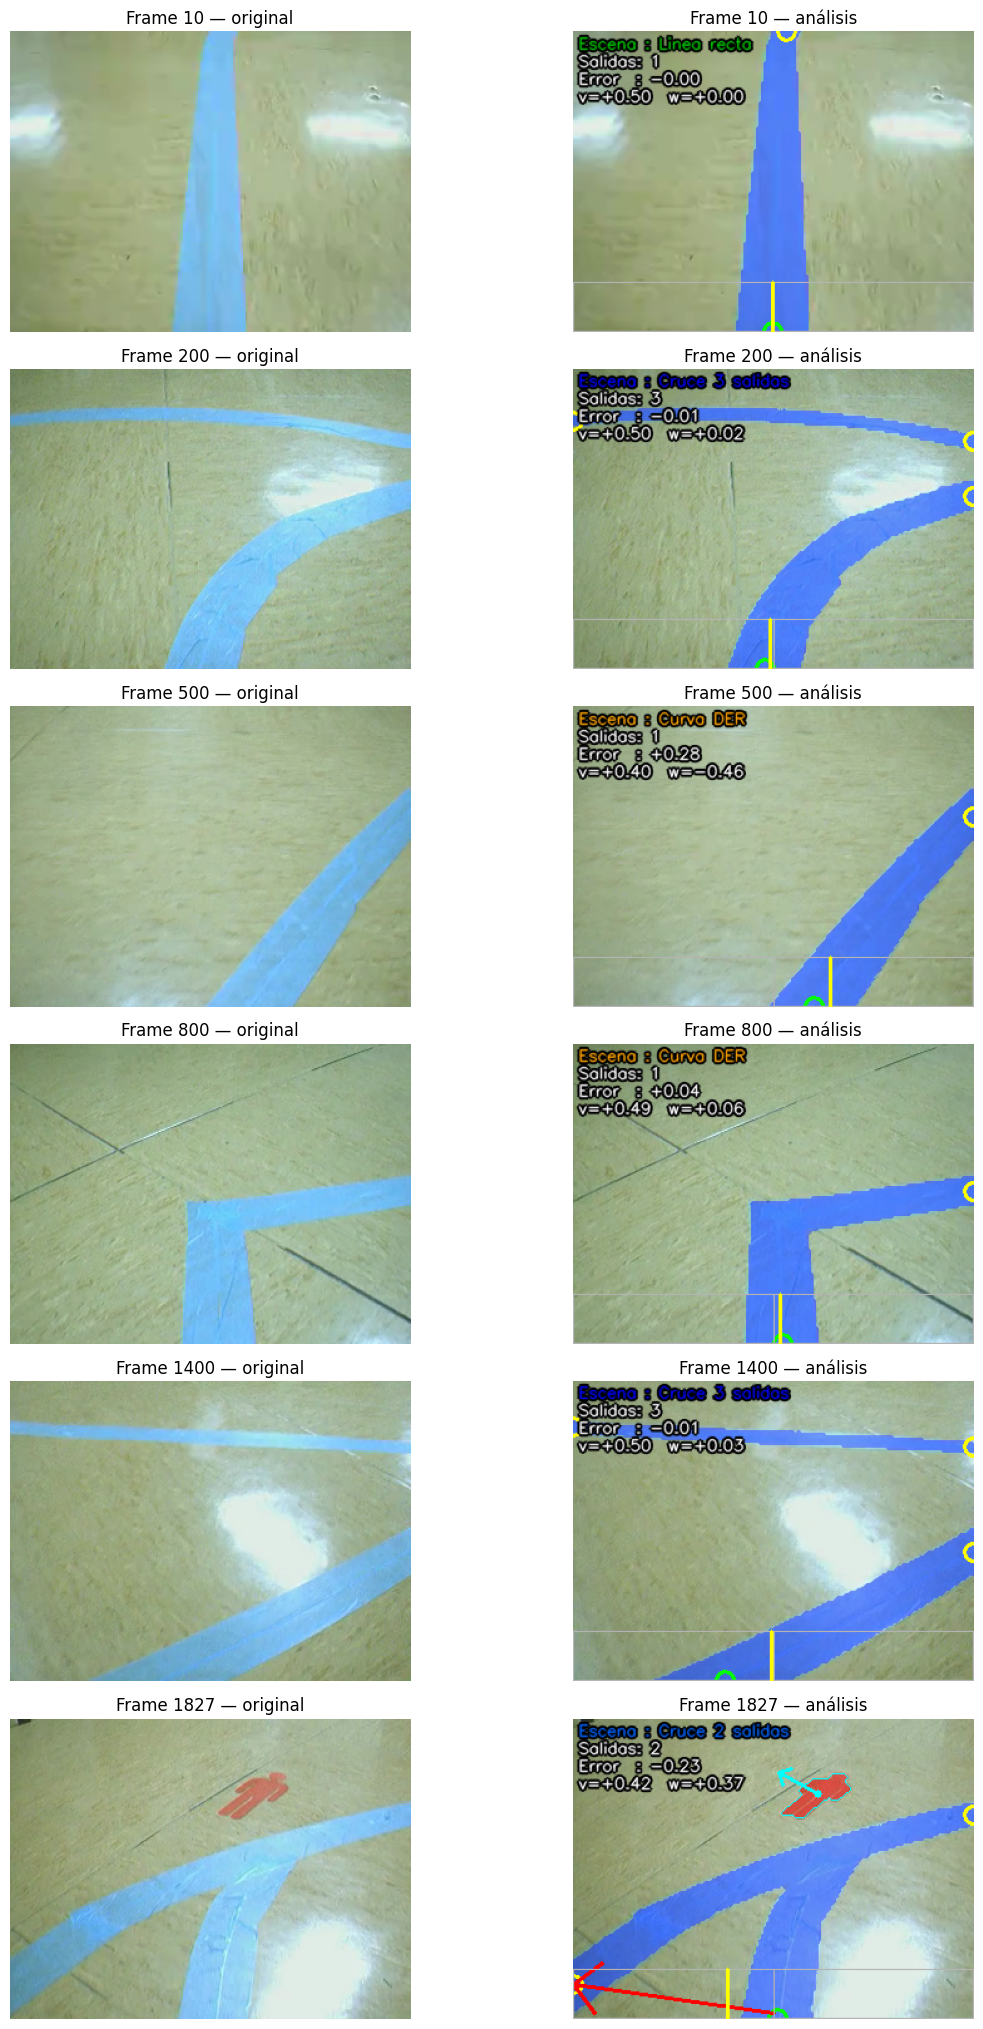

In [3]:
# Visualización de los frames demo con anotaciones
n = len(frames_demo)
fig, axs = plt.subplots(n, 2, figsize=(13, 3.4 * n))
if n == 1:
    axs = axs[None, :]
for row, (idx, rgb, res) in enumerate(frames_demo):
    bgr_an = ae.anotar_frame(rgb, res)
    axs[row, 0].imshow(rgb);                              axs[row, 0].set_title(f'Frame {idx} — original'); axs[row, 0].axis('off')
    axs[row, 1].imshow(cv2.cvtColor(bgr_an, cv2.COLOR_BGR2RGB)); axs[row, 1].set_title(f'Frame {idx} — análisis');  axs[row, 1].axis('off')
plt.tight_layout(); plt.show()

## 4. Clasificación de la escena

La función `clasificar_escena` decide a partir de los extremos detectados:

| Tipo | Condición |
|---|---|
| `sin_linea` | No hay extremos. |
| `fin_linea` | Hay entrada por debajo pero ninguna salida. |
| `recta`     | 1 entrada + 1 salida superior aproximadamente alineada (`±18 % W`). |
| `curva_izq` | 1 entrada + 1 salida en el lado izquierdo o esquina superior izquierda. |
| `curva_der` | 1 entrada + 1 salida en el lado derecho o esquina superior derecha. |
| `cruce_2`   | 1 entrada + 2 salidas (T o bifurcación). |
| `cruce_3`   | 1 entrada + 3 salidas (X). |

## 5. Orientación de la flecha / marca

Aplicamos el patrón sugerido en la página 72 de `transp.pdf`: ajustamos
una elipse al contorno de la marca (`cv2.fitEllipse`) y nos quedamos con
el ángulo del eje principal. El **sentido** (cabeza vs. cola) se decide
por la **asimetría** del contorno respecto al centroide a lo largo del
eje principal:

* En una flecha clásica la cabeza es más estrecha y corta que la cola.
* En las marcas-figura humana de este vídeo, la cabeza es también
  notablemente más pequeña que las piernas.

Por tanto el lado **menos extendido** del contorno es la dirección
apuntada. La **salida seleccionada** es la salida cuyo ángulo desde el
centro del frame es el más cercano al de la flecha.

## 6. Error de seguimiento

Solo nos interesa lo que el robot tiene **inmediatamente delante**
(suposición A2), así que medimos el error sobre la **banda inferior** del
frame (40 píxeles, ≈ 17 % de la altura). El error es la diferencia
horizontal entre el centro del robot (centro de la imagen) y el
centroide de los píxeles de línea en esa banda, normalizada al
intervalo `[-1, 1]`:

* `error = -1`  →  la línea está totalmente a la izquierda.
* `error = +1`  →  la línea está totalmente a la derecha.
* `error =  0`  →  la línea está centrada.

## 7. Consigna de control

El error se traduce a una consigna `(v, ω)` con un **PD** simple:

$$\omega = -K_p\, e \;-\; K_d\, \dot{e}, \qquad
  v = \max\!\bigl(v_{min},\; v_{max}(1 - \alpha\,|e|)\bigr).$$

La velocidad lineal se reduce con la magnitud del error (más cuidado en
curvas pronunciadas) y se anula cuando se pierde la línea, evitando que
el robot derive sin información. Los parámetros por defecto del módulo
(`Kp=1.2, Kd=0.4, v_max=0.5, v_min=0.05, α=0.7`) producen una respuesta
suave para los frames de `video1.mp4`; en una integración real
deberían afinarse según la cinemática del robot.

## 8. Validación sobre `video1.mp4`

Procesamos el vídeo entero, generamos `video1_control.mp4` con todas las
anotaciones (entradas, salidas, escena, flecha, banda de error, consigna)
y guardamos cinco frames de muestra para inspección.

In [4]:
INDICES_MUESTRA = {0, TOTAL // 4, TOTAL // 2, 3 * TOTAL // 4, TOTAL - 30}

control = ae.ControlPD(kp=1.2, kd=0.4, v_max=0.5, v_min=0.05, alpha_v=0.7)
res_video = ae.procesar_video('video1.mp4',
                              'video1_control.mp4',
                              clf=clf,
                              control=control,
                              indices_muestra=INDICES_MUESTRA,
                              verbose=True)

print(f"\nVídeo anotado: video1_control.mp4")
print(f"  Frames procesados: {res_video['n_frames']}")
print(f"  Tiempo medio por frame: {res_video['ms_frame']:.1f} ms  →  {1000/res_video['ms_frame']:.1f} FPS de procesado")

  Frame  200/1877   (12.6 ms/frame)


  Frame  400/1877   (9.7 ms/frame)


  Frame  600/1877   (9.6 ms/frame)


  Frame  800/1877   (8.7 ms/frame)


  Frame 1000/1877   (8.8 ms/frame)


  Frame 1200/1877   (8.1 ms/frame)


  Frame 1400/1877   (9.7 ms/frame)


  Frame 1600/1877   (9.2 ms/frame)


  Frame 1800/1877   (8.8 ms/frame)



Vídeo anotado: video1_control.mp4
  Frames procesados: 1877
  Tiempo medio por frame: 9.4 ms  →  106.0 FPS de procesado


In [5]:
# Distribución de tipos de escena
escenas = res_video['escenas']
total = sum(escenas.values())
print('Distribución de escenas en el vídeo:')
for tipo, n in escenas.most_common():
    print(f'  {tipo:11s} → {n:5d} frames  ({100*n/total:5.1f} %)')

Distribución de escenas en el vídeo:
  curva_der   →   741 frames  ( 39.5 %)
  cruce_2     →   508 frames  ( 27.1 %)
  cruce_3     →   488 frames  ( 26.0 %)
  recta       →   104 frames  (  5.5 %)
  sin_linea   →    32 frames  (  1.7 %)
  curva_izq   →     4 frames  (  0.2 %)


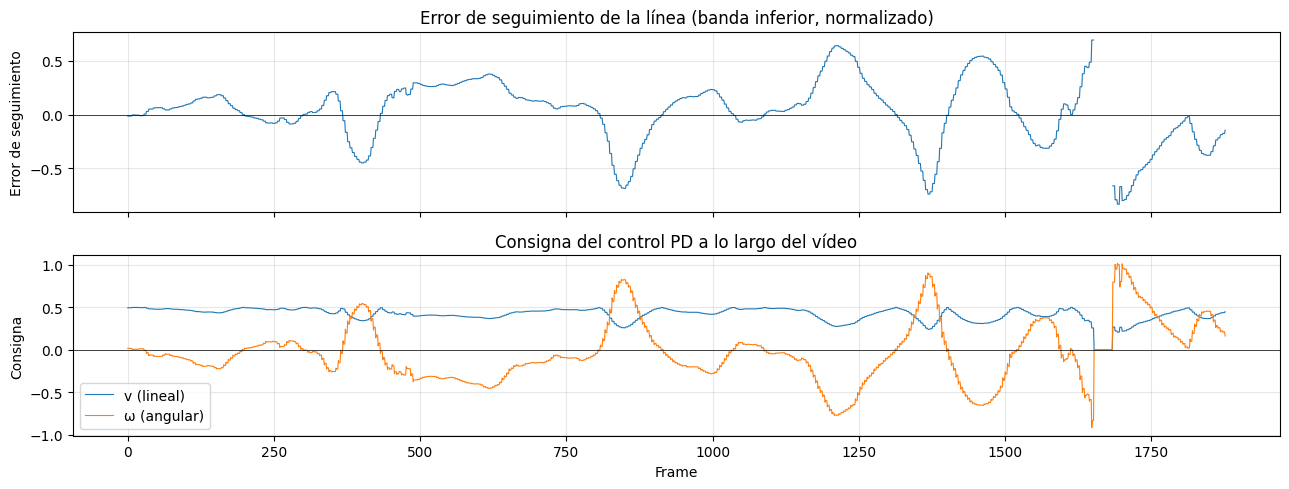

In [6]:
# Curvas de error y consigna a lo largo del vídeo
errores = np.array([(e if e is not None else np.nan) for e in res_video['errores']])
fig, axs = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axs[0].plot(errores, lw=0.8)
axs[0].axhline(0, color='k', lw=0.5)
axs[0].set_ylabel('Error de seguimiento')
axs[0].set_title('Error de seguimiento de la línea (banda inferior, normalizado)')
axs[0].grid(alpha=0.3)

# Recalculamos la consigna offline para visualizarla suavizada
ctrl = ae.ControlPD(kp=1.2, kd=0.4, v_max=0.5, v_min=0.05, alpha_v=0.7)
v = []; w = []
for e in res_video['errores']:
    a, b = ctrl.actualizar(e)
    v.append(a); w.append(b)
axs[1].plot(v, label='v (lineal)',  lw=0.8)
axs[1].plot(w, label='ω (angular)', lw=0.8)
axs[1].axhline(0, color='k', lw=0.5)
axs[1].set_xlabel('Frame')
axs[1].set_ylabel('Consigna')
axs[1].set_title('Consigna del control PD a lo largo del vídeo')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

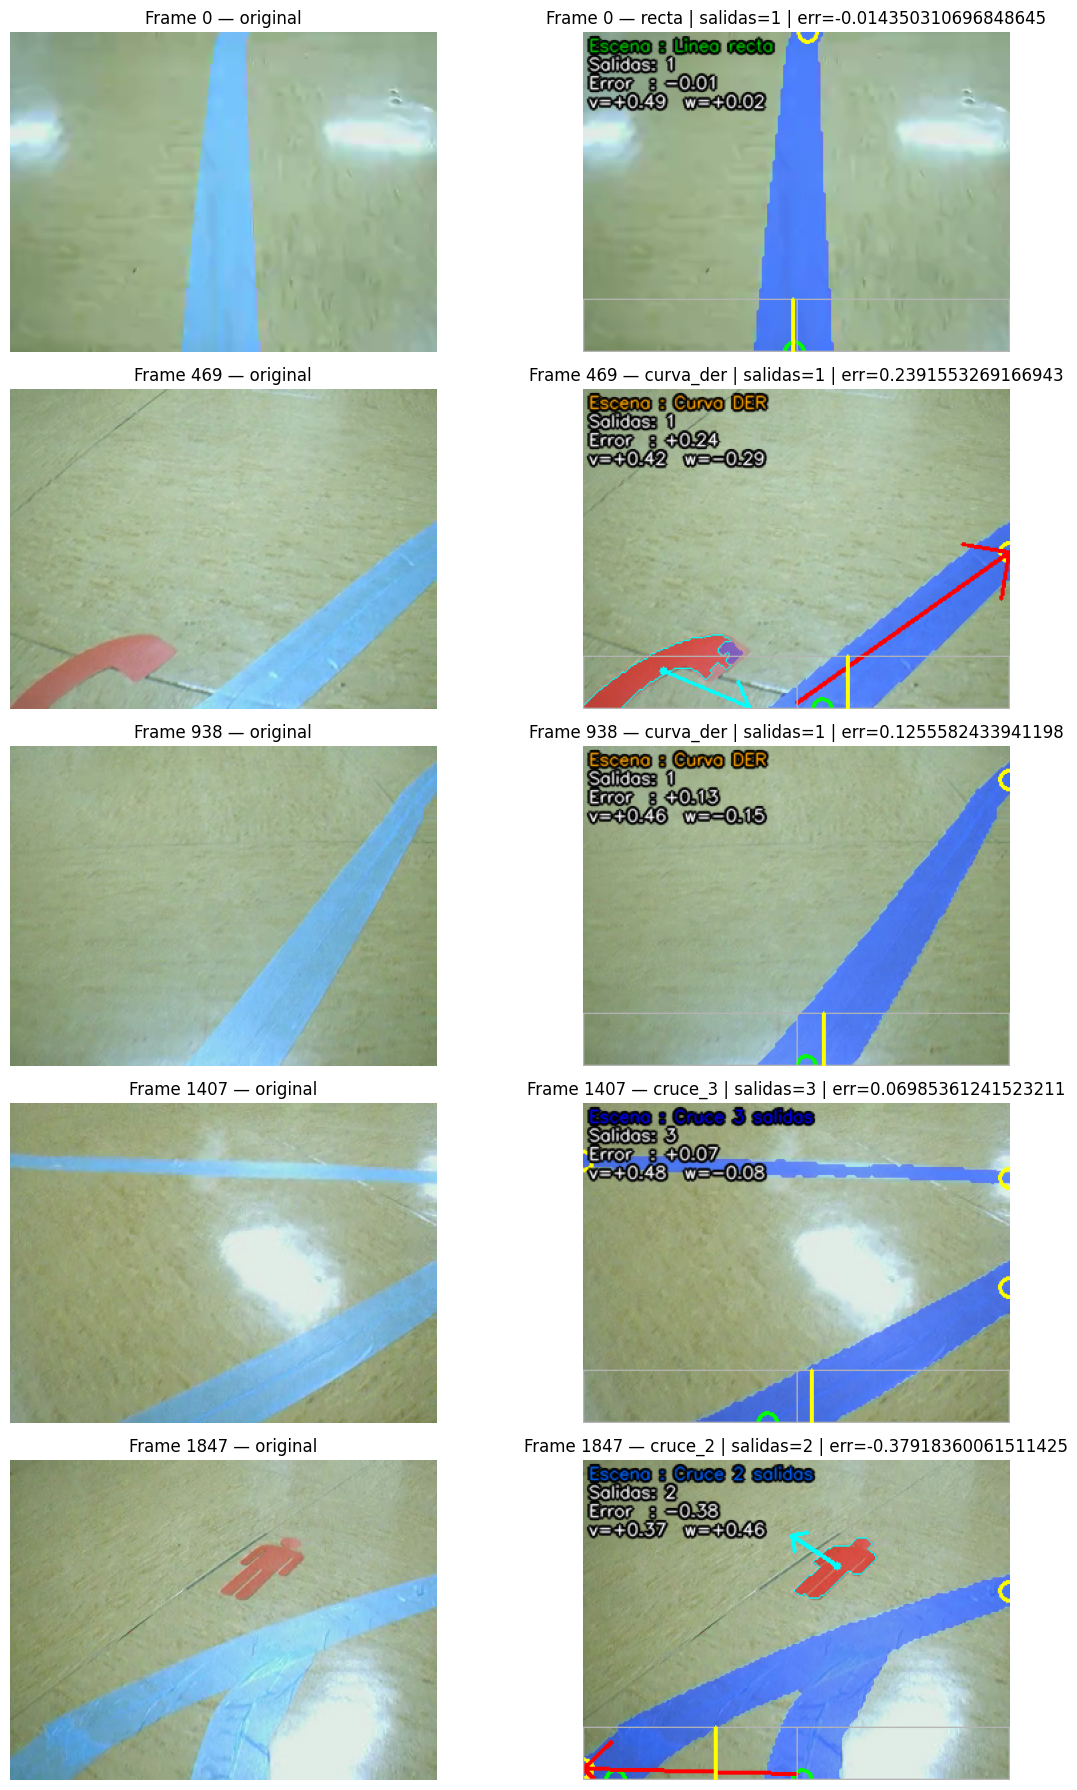

In [7]:
# Mosaico de los frames clave guardados
muestras = res_video['frames_muestra']
n = len(muestras)
fig, axs = plt.subplots(n, 2, figsize=(13, 3.6 * n))
if n == 1:
    axs = axs[None, :]
for row, (idx, rgb, bgr_an, r) in enumerate(muestras):
    axs[row, 0].imshow(rgb)
    axs[row, 0].set_title(f'Frame {idx} — original'); axs[row, 0].axis('off')
    axs[row, 1].imshow(cv2.cvtColor(bgr_an, cv2.COLOR_BGR2RGB))
    estado = f'{r.escena.tipo} | salidas={len(r.escena.salidas)} | err={r.error}' if r.error is not None else f'{r.escena.tipo}'
    axs[row, 1].set_title(f'Frame {idx} — {estado}'); axs[row, 1].axis('off')
plt.tight_layout(); plt.show()

## 9. Conclusiones

* Bajo las **siete suposiciones** descritas en §1, el problema de
  control se reduce a (i) decidir qué tipo de escena tenemos, (ii)
  identificar las salidas, (iii) elegir una en función de la flecha si
  está presente y (iv) producir una consigna `(v, ω)` que minimice el
  error de seguimiento.
* La **detección de extremos por componente conexa** es robusta: filtra
  automáticamente las falsas detecciones del QDA (sombras, bordes de
  baldosa) sin necesidad de un postproceso extra.
* La clasificación de escena trabaja sólo con el **número y posición**
  de las intersecciones con los bordes, lo que es invariante a la forma
  exacta de la línea y a pequeños cambios de iluminación.
* El **PD** elegido es la consigna mínima razonable; un control más
  sofisticado (PID con integral, *pure pursuit*, MPC) requeriría
  conocer el modelo cinemático real del robot, fuera del alcance de
  esta práctica de visión.